# Full factorial: the scaling law of a very small recurrent network

Not a hyperparameter search — a measurement. How much does training actually move when
the **update budget**, the **dataset size** or the **sequence length** change, and how
much of that movement is just the luck of the initial weights?

A full factorial design over those three factors, every cell replicated across several
initialisations, every design point checkpointed. The model is a deliberately tiny 3-unit
LSTM, the same one as the [lstm](../lstm/README.md) example.

The mechanics live in [helpers.py](./helpers.py); the reasoning behind every choice below
is in the [README](./README.md).

## The task

Classify a string of characters as valid or invalid under a tiny grammar:

$$
\begin{array}{rcl}
\langle\mathit{string}\rangle   & \mathrel{::=} & \langle\mathit{term}\rangle \\
                              & \mid          & \langle\mathit{string}\rangle \mathbin{\texttt{+}} \langle\mathit{term}\rangle \\[2pt]
\langle\mathit{term}\rangle   & \mathrel{::=} & AB, ED, OK \\[2pt]
\end{array}
$$

A valid string is a concatenation of the two-character terms `AB`, `ED`, `OK`. Datasets
come from `get_dataset(row, col)`: half grammatical, half uniform, every label obtained by
parsing. Characters are tokenized into *(is vowel, is consonant, position in alphabet)*.

→ [README: the task](./README.md#the-task-is-this-string-in-the-language)

## The three factors

| Factor | Levels |
| --- | --- |
| `updates` | 2048, 5096, 10192 |
| `number_of_sequence` | 256, 512, 1024 |
| `sequence_length` | 16, 32, 64 |

The budget is in **updates**, not epochs, so it is not confounded with the dataset size;
epochs are derived as $\lceil \text{updates} / \text{updates per epoch} \rceil$.
Everything else is held constant.

→ [README: the three factors](./README.md#the-three-factors)

## Replication and the two seed streams

One run per cell has no error term, and here the initialisation spread is larger than
every factor effect except the budget. So each cell is trained once per entry of `SEEDS`,
and the base seed feeds two streams: the **dataset** keyed on the cell, the **weights and
shuffle** keyed on the replicate. The design is therefore paired, and the replicate spread
is initialisation noise alone.

→ [README: replication and the two seed streams](./README.md#replication-and-the-two-seed-streams)

In [5]:
"""Static Hyperparameters Configuration"""

from examples.recurrent.scaling_law.helpers import Experiment

MAX_LR, MIN_LR = 1e-2, 1e-4

## Replicate indices. Every cell is trained once per entry, and the same entries are
## reused in every cell, so the whole grid is compared over one shared set of
## initialisations and the seed noise common to two cells cancels when they are compared.
SEEDS = (0, 1, 2)

## `seed` is the base of two separate streams, derived in helpers:
##   - data_seed_for(seed, n_seq, s_len)  the dataset, keyed on the cell
##   - init_seed_for(seed, replicate)     the weights and the shuffle, keyed on the replicate
## Seeding once and letting the draws run on would tie the initialisation to the dataset,
## since get_dataset consumes a number of draws that depends on both factors.
##
## A replicated sweep should write to its own folder: the older unreplicated study uses
## overlapping experiment ids and its artifacts carry no seed field, so it would be
## recovered as completed work of this design and silently skip runs.
experiment = Experiment(
    batch_size=16,
    split_ratio=0.9,
    seed=777,
    seeds=SEEDS,
    checkpoint_folder='./checkpoint',
)

## The model, and the cosine restart

A 3-unit LSTM into a linear layer and a sigmoid, with binary cross-entropy and SGD.

The `updates` factor is read off **checkpoints of a single run** rather than one run per
budget. That is only valid if the learning rate at a checkpoint does not depend on how
long the run continues afterwards — so the cosine **restarts at every checkpoint**,
annealing `MAX_LR -> MIN_LR` within each segment.

→ [README: the experiment](./README.md#the-experiment-27-design-points-for-the-price-of-9-runs)

In [6]:
"""Model Architecture"""

from thorcino.activations import Sigmoid
from thorcino.layers.linear import Linear
from thorcino.layers.lstm import LSTM
from thorcino.layers.sequential import Sequential
from thorcino.losses import BinaryCrossEntropyLoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineRestartSchedule
from thorcino.training.trainer import Trainer

def make_trainer(checkpoint_epochs: list[int]) -> Trainer:
    model = Sequential(
        LSTM(in_feature=3, hidden_units=3, out_type='n_to_1'),
        Linear(in_feature=3, out_feature=1),
        Sigmoid(),
    )
    loss = BinaryCrossEntropyLoss()
    optimizer = SGD(model.parameters, MAX_LR)
    scheduler = CosineRestartSchedule(MAX_LR, MIN_LR, [e + 1 for e in checkpoint_epochs])

    return Trainer(model, loss, optimizer, scheduler)

## The validation set

One shared, fixed validation set, built as one sub-set per length — `[8, 16, 32, 64, 96]`,
500 sequences each — spanning below and above the training lengths, so length
generalization is visible.

Each validation artifact holds one score **per validation length**, not per epoch.

→ [README: the validation set](./README.md#the-validation-set)

In [7]:
"""Create the Validation Set"""

VAL_SEQUENCE_LENGTHS = [8, 16, 32, 64, 96]

val_dataset = experiment.validation_set(500, VAL_SEQUENCE_LENGTHS)

validation set: SEQUENCE_LENGTH=8 X=(500, 8, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=16 X=(500, 16, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=32 X=(500, 32, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=64 X=(500, 64, 3) Y=(500, 1) positives=0.500
validation set: SEQUENCE_LENGTH=96 X=(500, 96, 3) Y=(500, 1) positives=0.500


## Running the sweep

9 cells x `len(SEEDS)` replicates, each trained to the largest budget with the smaller
budgets harvested as checkpoints — the full 27 design points per replicate for the cost of
the largest budget. Roughly 30 minutes per replicate.

**Interruptible:** artifacts are named by a deterministic id, so a re-run skips completed
work and resumes from the last checkpoint.

→ [README: artifacts and checkpoint recovery](./README.md#artifacts-and-checkpoint-recovery)

In [ ]:
"""Running the Full Factorial"""

hyperparams = {
    'updates': [2048, 5096, 10192],
    'number_of_sequence': [256, 512, 1024],
    'sequence_length': [16, 32, 64]
}

completed_checkpoints = experiment.run_full_factorial(hyperparams, make_trainer, val_dataset)

recovered 0 completed checkpoint(s): []
planning 9 cells x 3 replicate(s) x 3 budgets = 81 design points

-----------------NEW EXPERIMENT STARTED-----------------
experiment hyperparameters: EPOCHS=680 UPDATES=10192, NUMBER_OF_SEQUENCE=256, SEQUENCE_LENGTH=16
replicate 1/3: SEED=0 (data_seed=1256793, init_seed=777)
updates per epoch: 15, checkpoint epochs: [136, 339, 679]


## How much replication is on disk?

A cell holding a single artifact still plots — as a line with a zero-width band, which
reads as a precise measurement rather than a missing one. This is the check that says
which design points have an error term.

In [ ]:
from examples.recurrent.scaling_law.helpers import FullFactorialMetrics

validation_metrics = FullFactorialMetrics(experiment.validation_folder)

In [ ]:
"""Replicates per design point."""

from examples.recurrent.scaling_law.helpers import replication_report

print(replication_report(validation_metrics.metrics, hyperparams))


## From artifacts to a response surface

Two reductions before anything is drawn: **over validation lengths** (`eval_index=None`
averages, an integer picks one) and **over replicates** (median, with a min-max band on
the flat curves). Only the last epoch of each run is used, and the median — never the best
run, which is a biased estimator whose bias grows with the cell's variance.

→ [README: why the median, never the best](./README.md#why-the-median-never-the-best)

In [ ]:
"""Group the validation artifacts by sequence length (the panel axis)."""

grouped_metrics = []
for seq_len in hyperparams['sequence_length']:
    grouped_metrics.append({
        'sequence_length': seq_len,
        'metrics': [x for x in validation_metrics.metrics if x.metadata.sequence_length == seq_len],
    })

for group in grouped_metrics:
    print(f"sequence_length={group['sequence_length']}: {len(group['metrics'])} artifact(s)")

### Surfaces — the shape

Three factors and one response are four dimensions, so the sequence length goes on the
**panels**: each panel is a real `updates x number of sequences` slice at one length. Both
factor axes are $\log_2$ distance from the middle level. The black dots are the nine real
measurements a surface is drawn between.

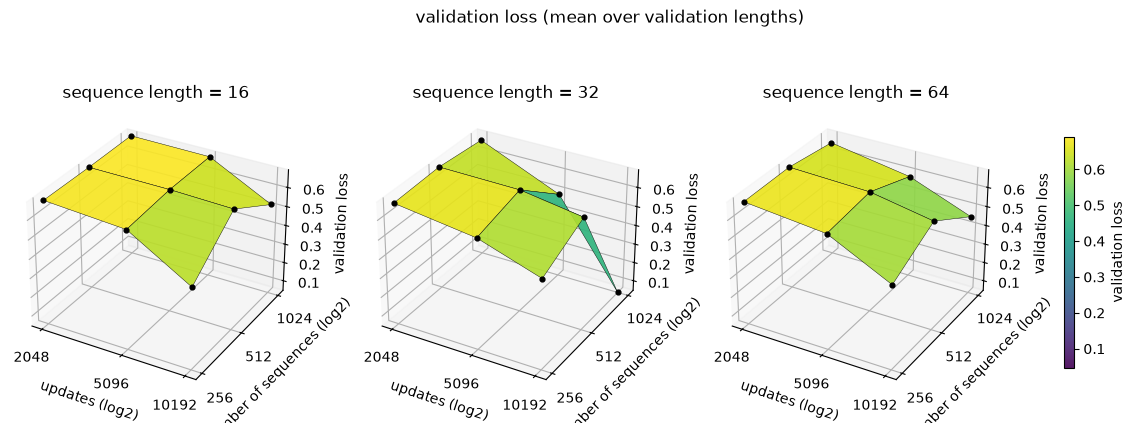

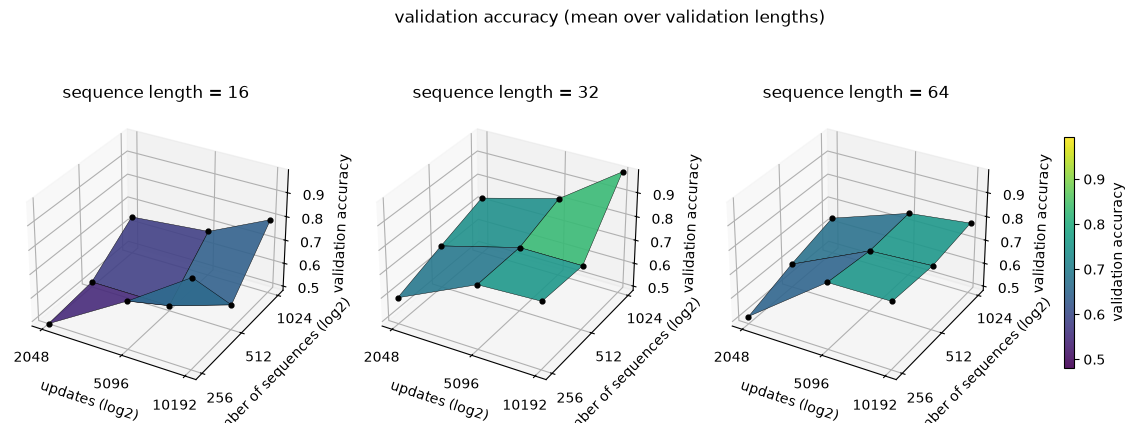

In [ ]:
"""Validation metrics as surfaces, one panel per sequence length."""

import matplotlib.pyplot as plt

from examples.recurrent.scaling_law.helpers import plot_metric_surfaces

fig = plot_metric_surfaces(grouped_metrics, hyperparams, 'loss_history')
plt.show()

fig = plot_metric_surfaces(grouped_metrics, hyperparams, 'accuracy_history')
plt.show()

### Log-log curves — the rate

The exponent of a scaling law is a slope, read far more reliably off a line than off a
tilted surface. The shaded band is the spread over initialisations: **where it is wide
compared to the gap between two lines, this grid has not told those levels apart**,
however clean the medians look.

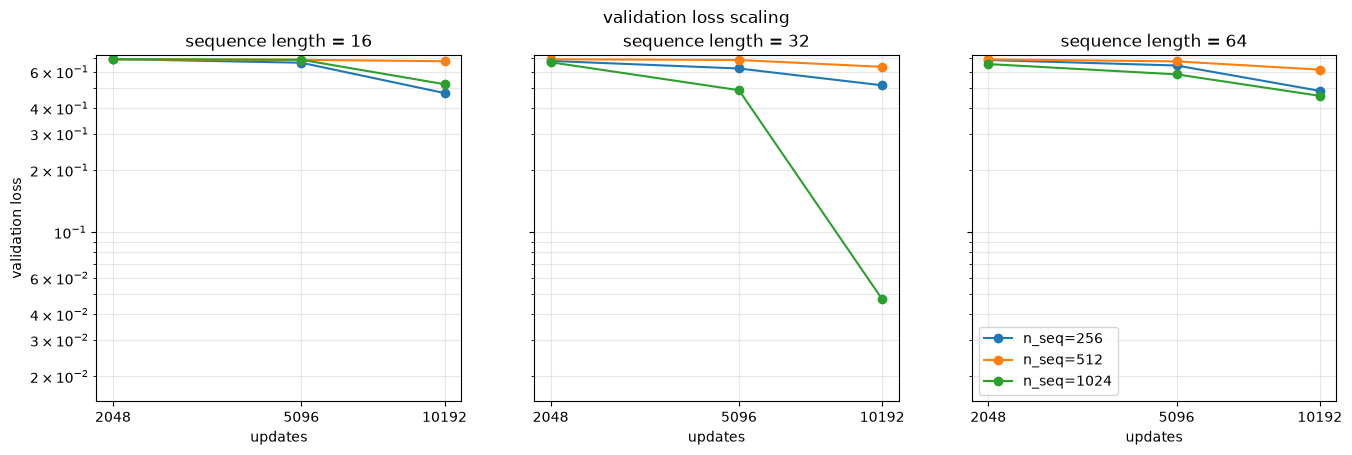

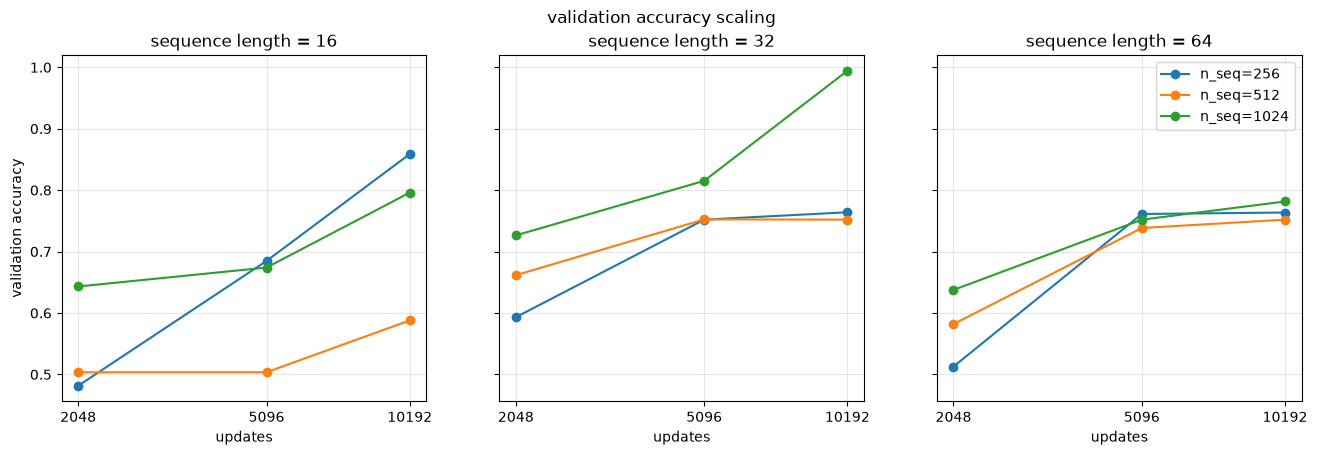

In [ ]:
"""Validation metrics as log-log scaling curves."""

from examples.recurrent.scaling_law.helpers import plot_metric_scaling

fig = plot_metric_scaling(grouped_metrics, hyperparams, 'loss_history')
plt.show()

fig = plot_metric_scaling(grouped_metrics, hyperparams, 'accuracy_history')
plt.show()


## What this grid can and cannot say

The **budget is the binding constraint** — almost every curve is still rising at the
largest budget, and it is the one effect that clears the seed spread. The dataset-size
axis is flat and not even monotonic, which is variance showing through the design. Length
costs accuracy, not learnability.

This grid locates the binding factor; it does not have the resolution to fit an exponent.

→ [README: results](./README.md#results)